# Tugas Praktikum Data Mining II - TM7

## Nama: Faiz Iqbal I'tishom
## NIM: 164231059
## Kelas: SD-A2

# Informasi Dataset

In [33]:
import pandas as pd
import numpy as np
import networkx as nx
import re, string, os
import matplotlib.pyplot as plt

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import opinion_lexicon
from nltk.tokenize import word_tokenize

# Modeling tools
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score, classification_report

import torch

os.environ["WANDB_MODE"] = "disable"  

df = pd.read_csv("C:/Uner/Semester 5/Data Mining II/Coolyeah/TM7/Data_Data Mining II TM7.csv")


df_id = df[df['lang'] == 'in'][['created_at', 'full_text']].copy()

n_samples = min(2000, len(df_id))

df_id = df_id.sample(n=n_samples, random_state=42).reset_index(drop=True)

print(f"Jumlah data setelah sampling: {len(df_id)}")
df_id.head()

Jumlah data setelah sampling: 2000


,created_at,full_text
0,2025-03-11 03:16:58+00:00,Dampak efisiensi buat danantara atau lebih coc...
1,2025-03-10 01:58:02+00:00,Danantara mempercepat tercapainya pertumbuhan ...
2,2025-02-26 05:04:12+00:00,@hexagrap_id Optimalkan aset BUMN dengan inves...
3,2025-02-27 00:07:56+00:00,Pertamax oplosan langsung menggantikan riuh ge...
4,2025-04-03 18:41:19+00:00,Struktur kepemimpinan Danantara melibatkan tok...


## Statistika Deskriptif

In [34]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import seaborn as sns
import numpy as np

def plot_top_words(df, text_col="full_text", top_n=20):
    all_words = " ".join(df[text_col].astype(str)).lower().split()
    counter = Counter(all_words)
    most_common = counter.most_common(top_n)
    words, counts = zip(*most_common)

    plt.figure(figsize=(10,6))
    sns.barplot(x=list(counts), y=list(words), palette="crest")
    plt.title(f"Top {top_n} Most Frequent Words", fontsize=14)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_wordcloud(df, text_col="full_text"):
    text = " ".join(df[text_col].astype(str))
    wc = WordCloud(width=1000, height=600, background_color='white', colormap='viridis').generate(text)

    plt.figure(figsize=(10,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud of Tweets", fontsize=14)
    plt.show()

In [36]:
def build_mention_graph(df, text_col="full_text", user_col="username"):
    G = nx.DiGraph()
    for _, row in df.iterrows():
        user = row[user_col] if user_col in df.columns else "unknown"
        text = str(row[text_col]).lower()
        mentions = re.findall(r"@([A-Za-z0-9_]+)", text)
        for mentioned in mentions:
            if user != mentioned:
                G.add_edge(user, mentioned)
    print(f"✅ Mention graph dibuat: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G

In [37]:
def build_hashtag_graph(df, text_col="full_text"):
    G = nx.Graph()
    for _, row in df.iterrows():
        text = str(row[text_col]).lower()
        hashtags = re.findall(r"#(\w+)", text)
        for i in range(len(hashtags)):
            for j in range(i + 1, len(hashtags)):
                G.add_edge(hashtags[i], hashtags[j])
    print(f"✅ Hashtag graph dibuat: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G

✅ Mention graph dibuat: 13263 nodes, 19573 edges
✅ Hashtag graph dibuat: 1347 nodes, 6168 edges


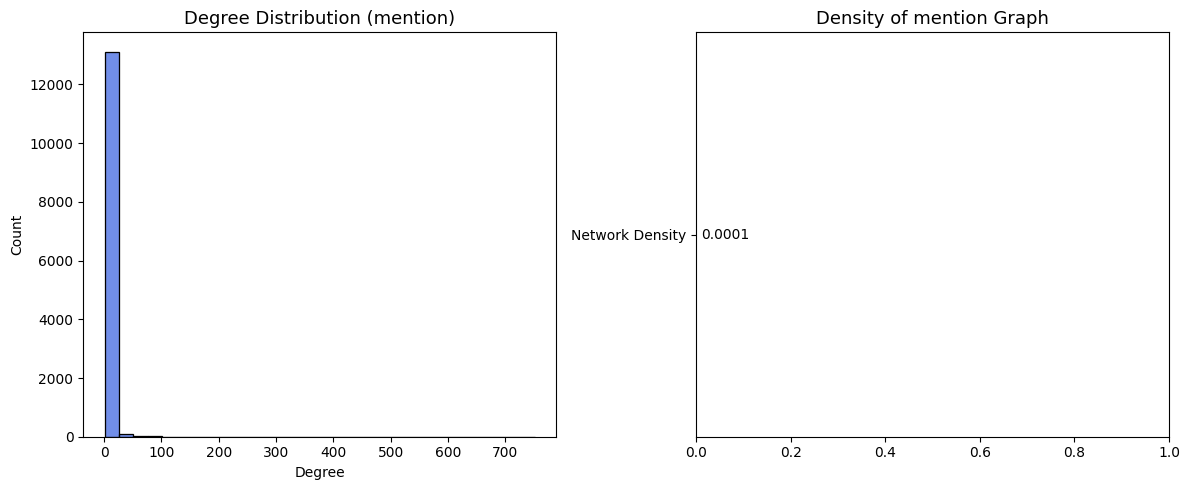

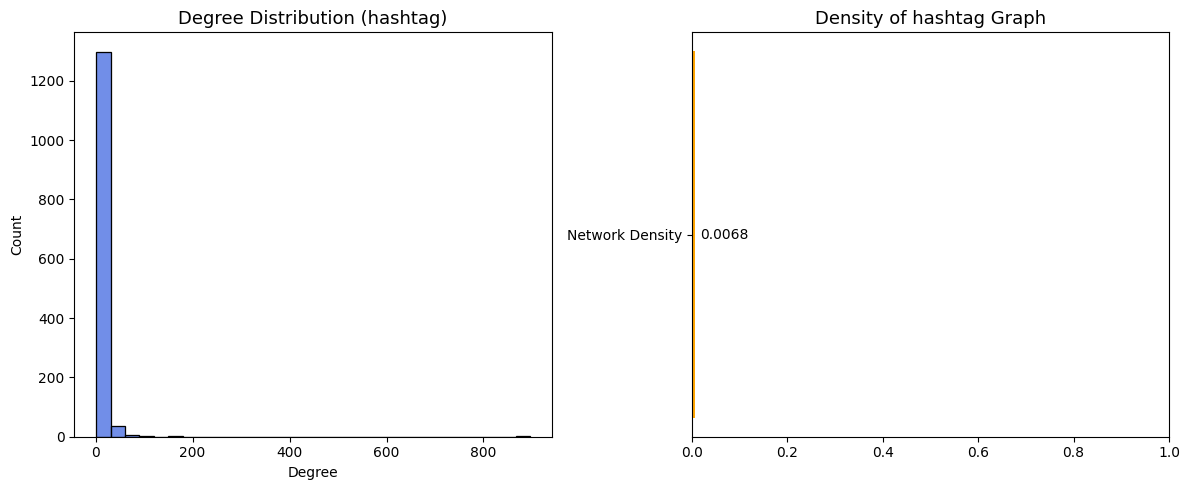

In [38]:
G_mention = build_mention_graph(df, text_col="full_text", user_col="username")
G_hashtag = build_hashtag_graph(df, text_col="full_text")

plot_graph_statistics(G_mention, prefix="mention")
plot_graph_statistics(G_hashtag, prefix="hashtag")

## Pre-Processing

In [39]:
stop_factory = StopWordRemoverFactory()
stopwords_id = set(stop_factory.get_stop_words())
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

In [40]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)      
    text = re.sub(r"@\w+|#\w+|\d+", "", text)              
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in stopwords_id]
    return " ".join(tokens)

df_id['clean_text'] = df_id['full_text'].astype(str).apply(clean_text)

In [41]:
from nltk.corpus import opinion_lexicon
import nltk
nltk.download('opinion_lexicon')
nltk.download('punkt')

positive_lexicon = set(opinion_lexicon.positive())
negative_lexicon = set(opinion_lexicon.negative())

indo_pos = {"baik", "bagus", "hebat", "terbaik", "lancar", "sukses", "cepat", "nyaman", "puas", "ramah"}
indo_neg = {"buruk", "jelek", "lambat", "gagal", "bohong", "parah", "benci", "marah", "mahal", "sulit"}

positive_words = positive_lexicon.union(indo_pos)
negative_words = negative_lexicon.union(indo_neg)

def lexicon_sentiment(text):
    tokens = text.split()
    pos_count = sum(1 for t in tokens if t in positive_words)
    neg_count = sum(1 for t in tokens if t in negative_words)
    if pos_count > neg_count:
        return 2  
    elif neg_count > pos_count:
        return 0  
    else:
        return 1 
        
df_id['label'] = df_id['clean_text'].apply(lexicon_sentiment)

print(df_id['label'].value_counts())

label
1    1646
2     244
0     110
Name: count, dtype: int64


[nltk_data] Downloading package opinion_lexicon to C:\Users\Faiz
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Faiz
[nltk_data]     Iqbal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Visualisasi

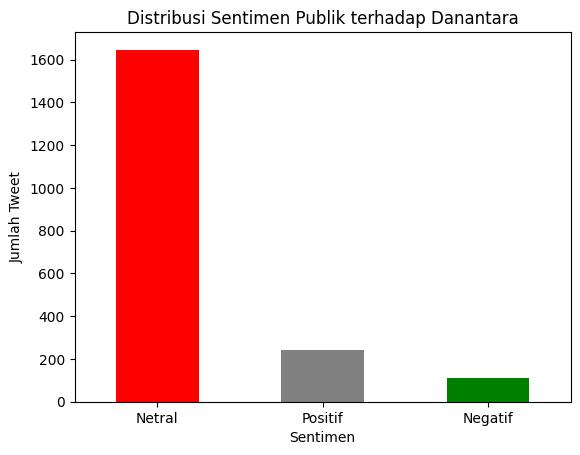

In [42]:
label_map = {0: "Negatif", 1: "Netral", 2: "Positif"}
df_id['sentimen'] = df_id['label'].map(label_map)
df_id['sentimen'].value_counts().plot(kind='bar', color=['red', 'gray', 'green'])
plt.title("Distribusi Sentimen Publik terhadap Danantara")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Tweet")
plt.xticks(rotation=0)
plt.show()

## BERT

In [43]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_id['clean_text'].tolist(),
    df_id['label'].tolist(),
    test_size=0.2,
    stratify=df_id['label'],
    random_state=42
)

model_name = "indobenchmark/indobert-base-p1"
tokenizer = BertTokenizer.from_pretrained(model_name)

In [44]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'label': train_labels
})

val_dataset = Dataset.from_dict({
    'input_ids': val_encodings['input_ids'],
    'attention_mask': val_encodings['attention_mask'],
    'label': val_labels
})

model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [45]:
import inspect
import numpy as np
import torch
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, DataCollatorWithPadding, BertForSequenceClassification, BertTokenizer
from sklearn.metrics import accuracy_score, classification_report

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'accuracy': accuracy_score(labels, preds)}

sig = inspect.signature(TrainingArguments.__init__)
supported_params = set(sig.parameters.keys())

common_kwargs = dict(
    output_dir="./indoBERT-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
)

modern_extra = dict(
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    logging_steps=100,
    fp16=torch.cuda.is_available()
)

legacy_extra = dict(
    do_eval=True,
    evaluate_during_training=True,
    eval_steps=500,
    save_steps=500,
    logging_steps=100
)

if "evaluation_strategy" in supported_params:
    chosen = {**common_kwargs, **modern_extra}
else:
    chosen = {**common_kwargs, **legacy_extra}

filtered_kwargs = {k: v for k, v in chosen.items() if k in supported_params}

print("Detected TrainingArguments signature supports keys:", sorted(list(supported_params))[:10], "...")
print("Creating TrainingArguments with keys:", sorted(filtered_kwargs.keys()))

training_args = TrainingArguments(**filtered_kwargs)

try:
    model
    tokenizer
    train_dataset
    val_dataset
    data_collator
except NameError:
    print("Beberapa variabel (model/tokenizer/dataset) tidak ditemukan. Pastikan kamu menjalankan blok pembuatan dataset/tokenizer/model sebelumnya.")
    raise

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] if "EarlyStoppingCallback" in globals() else None
)

import traceback
try:
    trainer.train()
    print("TRAINING FINISHED")
    preds = trainer.predict(val_dataset)
    ypred = np.argmax(preds.predictions, axis=1)
    print(classification_report(val_labels, ypred, digits=4))
except Exception as e:
    print("TRAINER ERROR:", e)
    print(traceback.format_exc())
    print("\nJika error tetap muncul, tolong pastekan full traceback di sini.")


C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_35224\397880184.py:66: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Detected TrainingArguments signature supports keys: ['accelerator_config', 'adafactor', 'adam_beta1', 'adam_beta2', 'adam_epsilon', 'auto_find_batch_size', 'average_tokens_across_devices', 'batch_eval_metrics', 'bf16', 'bf16_full_eval'] ...
Creating TrainingArguments with keys: ['do_eval', 'eval_steps', 'learning_rate', 'logging_dir', 'logging_steps', 'num_train_epochs', 'output_dir', 'per_device_eval_batch_size', 'per_device_train_batch_size', 'save_steps', 'weight_decay']


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


TRAINER ERROR: EarlyStoppingCallback requires metric_for_best_model to be defined
Traceback (most recent call last):
  File "C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_35224\397880184.py", line 79, in <module>
    trainer.train()
    ~~~~~~~~~~~~~^^
  File "C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python313\site-packages\transformers\trainer.py", line 2325, in train
    return inner_training_loop(
        args=args,
    ...<2 lines>...
        ignore_keys_for_eval=ignore_keys_for_eval,
    )
  File "C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python313\site-packages\transformers\trainer.py", line 2573, in _inner_training_loop
    self.control = self.callback_handler.on_train_begin(args, self.state, self.control)
                   ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python313\site-packages\transformers\trainer_callback.py", line 506, in on_train_begin
    return self.call_event("on_train_begin", 

In [46]:
import time

print("\n🚀 Mulai training IndoBERT Sentiment Model...\n")
start_time = time.time()

try:
    train_result = trainer.train()
    trainer.save_model("./indoBERT-sentiment-final")
    print("\n✅ TRAINING SELESAI.")
except Exception as e:
    print("❌ TRAINING ERROR:", e)
    print(traceback.format_exc())

elapsed = time.time() - start_time
print(f"\n⏱️ Total waktu training: {elapsed/60:.2f} menit")


🚀 Mulai training IndoBERT Sentiment Model...



Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


❌ TRAINING ERROR: EarlyStoppingCallback requires metric_for_best_model to be defined
Traceback (most recent call last):
  File "C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_35224\717655691.py", line 7, in <module>
    train_result = trainer.train()
  File "C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python313\site-packages\transformers\trainer.py", line 2325, in train
    return inner_training_loop(
        args=args,
    ...<2 lines>...
        ignore_keys_for_eval=ignore_keys_for_eval,
    )
  File "C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python313\site-packages\transformers\trainer.py", line 2573, in _inner_training_loop
    self.control = self.callback_handler.on_train_begin(args, self.state, self.control)
                   ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python313\site-packages\transformers\trainer_callback.py", line 506, in on_train_begin
    return self.call_event("on_train_begin", arg

In [47]:
print("\n📊 Evaluasi model pada validation dataset...\n")

preds_output = trainer.predict(val_dataset)
preds = np.argmax(preds_output.predictions, axis=1)

print("=== Classification Report ===")
print(classification_report(val_labels, preds, digits=4))


C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



📊 Evaluasi model pada validation dataset...



=== Classification Report ===
              precision    recall  f1-score   support

           0     0.0909    0.0455    0.0606        22
           1     0.8170    0.7872    0.8019       329
           2     0.0694    0.1020    0.0826        49

    accuracy                         0.6625       400
   macro avg     0.3258    0.3116    0.3150       400
weighted avg     0.6855    0.6625    0.6730       400



C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_35224\4135283201.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=eval_df, x='pred_label', palette='viridis')


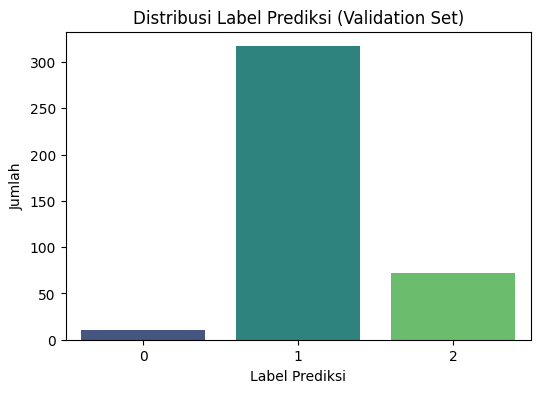

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
eval_df = pd.DataFrame({
    'text': val_texts,
    'true_label': val_labels,
    'pred_label': preds
})

plt.figure(figsize=(6,4))
sns.countplot(data=eval_df, x='pred_label', palette='viridis')
plt.title("Distribusi Label Prediksi (Validation Set)")
plt.xlabel("Label Prediksi")
plt.ylabel("Jumlah")
plt.show()

## Social Network Analysis

In [49]:
import re
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import csv
import os

try:
    from pyvis.network import Network
    HAS_PYVIS = True
except Exception:
    HAS_PYVIS = False

In [50]:

if 'df_id' not in globals():
    raise RuntimeError("DataFrame `df_id` tidak ditemukan. Jalankan preprocessing sebelumnya dulu.")

user_col = None
for c in ['user_screen_name', 'screen_name', 'username', 'user', 'author', 'user_name']:
    if c in df_id.columns:
        user_col = c
        break

if user_col is None:
    df_id = df_id.reset_index(drop=True)
    df_id['author'] = df_id.index.map(lambda i: f"user_{i}")
    user_col = 'author'
    print("Kolom user tidak ditemukan. Dibuat kolom 'author' dummy.")

Kolom user tidak ditemukan. Dibuat kolom 'author' dummy.


In [51]:
mention_pattern = re.compile(r"@([A-Za-z0-9_]+)")
hashtag_pattern = re.compile(r"#(\w+)")

def extract_mentions(text):
    if not isinstance(text, str):
        return []
    return mention_pattern.findall(text)

def extract_hashtags(text):
    if not isinstance(text, str):
        return []
    return [h.lower() for h in hashtag_pattern.findall(text)]

In [52]:
G_mention = nx.DiGraph()
edges_mention = [] 

for _, row in df_id.iterrows():
    author = str(row[user_col])
    mentions = extract_mentions(row.get('full_text', '') or row.get('clean_text', '') or '')
    for m in mentions:
        edges_mention.append((author, m.lower()))

if 'in_reply_to_screen_name' in df_id.columns:
    for _, row in df_id.dropna(subset=['in_reply_to_screen_name']).iterrows():
        edges_mention.append((str(row[user_col]), str(row['in_reply_to_screen_name']).lower()))
if 'retweeted_screen_name' in df_id.columns:
    for _, row in df_id.dropna(subset=['retweeted_screen_name']).iterrows():
        edges_mention.append((str(row[user_col]), str(row['retweeted_screen_name']).lower()))
if 'retweeted_status.user.screen_name' in df_id.columns:
    for _, row in df_id.dropna(subset=['retweeted_status.user.screen_name']).iterrows():
        edges_mention.append((str(row[user_col]), str(row['retweeted_status.user.screen_name']).lower()))

G_mention.add_edges_from(edges_mention)
print(f"Mention edges: {len(edges_mention)}, nodes: {G_mention.number_of_nodes()}")

Mention edges: 1603, nodes: 1797


In [53]:
G_hashtag = nx.Graph()
cooc_counts = Counter()

for _, row in df_id.iterrows():
    hashtags = list(dict.fromkeys(extract_hashtags(row.get('full_text', '') or row.get('clean_text', ''))))  # uniq preserve order
    if len(hashtags) < 2:
        continue
    for i in range(len(hashtags)):
        for j in range(i+1, len(hashtags)):
            a, b = sorted([hashtags[i], hashtags[j]])
            cooc_counts[(a,b)] += 1

for (a,b), w in cooc_counts.items():
    G_hashtag.add_edge(a, b, weight=w)

print(f"Hashtag graph: edges {G_hashtag.number_of_edges()}, nodes {G_hashtag.number_of_nodes()}")

Hashtag graph: edges 937, nodes 248


In [54]:
def compute_and_save_centralities(G, prefix="mention"):
    if G.number_of_nodes() == 0:
        print(f"Graph {prefix} kosong — skip centrality.")
        return None

    if G.is_directed():
        deg_in = dict(G.in_degree())
        deg_out = dict(G.out_degree())
    else:
        deg_in = deg_out = dict(G.degree())

    bet = nx.betweenness_centrality(G, k=100, seed=42) if G.number_of_nodes() > 1000 else nx.betweenness_centrality(G)
    try:
        pr = nx.pagerank(G)
    except Exception:
        pr = {n: 0.0 for n in G.nodes()}

    try:
        if not G.is_directed():
            ev = nx.eigenvector_centrality_numpy(G)
        else:
            ev = nx.eigenvector_centrality_numpy(G.to_undirected())
    except Exception:
        ev = {n: 0.0 for n in G.nodes()}

    rows = []
    for n in G.nodes():
        rows.append({
            'node': n,
            'degree_in': deg_in.get(n, 0),
            'degree_out': deg_out.get(n, 0),
            'betweenness': bet.get(n, 0),
            'pagerank': pr.get(n, 0),
            'eigenvector': ev.get(n, 0)
        })
    df_cent = pd.DataFrame(rows).sort_values('pagerank', ascending=False).reset_index(drop=True)
    csv_name = f"{prefix}_centrality_summary.csv"
    df_cent.to_csv(csv_name, index=False)
    print(f"Saved centrality summary to {csv_name}")
    return df_cent

df_mention_cent = compute_and_save_centralities(G_mention, prefix="mention")
df_hashtag_cent = compute_and_save_centralities(G_hashtag, prefix="hashtag")

if df_mention_cent is not None:
    print("\nTop 20 nodes (mention) by PageRank:")
    print(df_mention_cent[['node','pagerank','degree_in','degree_out']].head(20))

Saved centrality summary to mention_centrality_summary.csv
Saved centrality summary to hashtag_centrality_summary.csv

Top 20 nodes (mention) by PageRank:
               node  pagerank  degree_in  degree_out
0     genznusantara  0.013197         40           0
1       sbyudhoyono  0.012428         45           0
2           prabowo  0.009703         71           0
3          rtpvnews  0.007588         25           0
4          arsipaja  0.006413         20           0
5        tempodotco  0.006119         25           0
6    profesor_saham  0.005590         23           0
7   leonpriceleon48  0.005184         15           0
8      cnnindonesia  0.005024         16           0
9    democrazymedia  0.004703         14           0
10    dheppylovelly  0.003581         10           0
11         detikcom  0.003368         12           0
12         kompastv  0.003261         10           0
13      hexagrap_id  0.003261          9           0
14        kompascom  0.003207         12          

Community detection berhasil — total: 347 komunitas


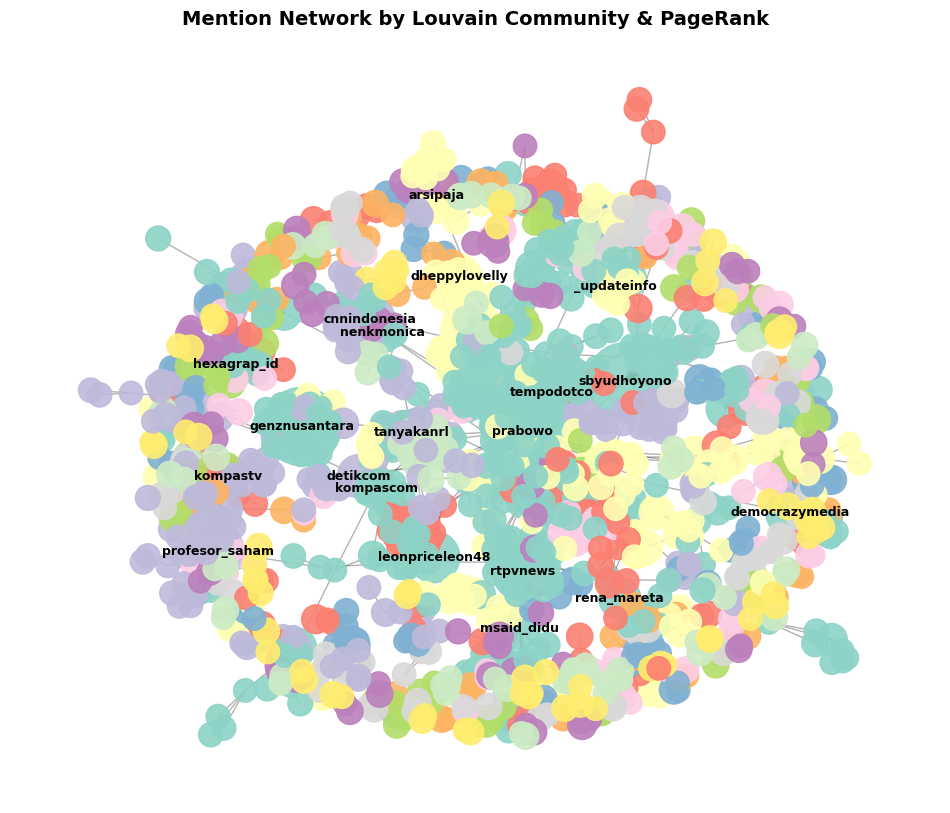

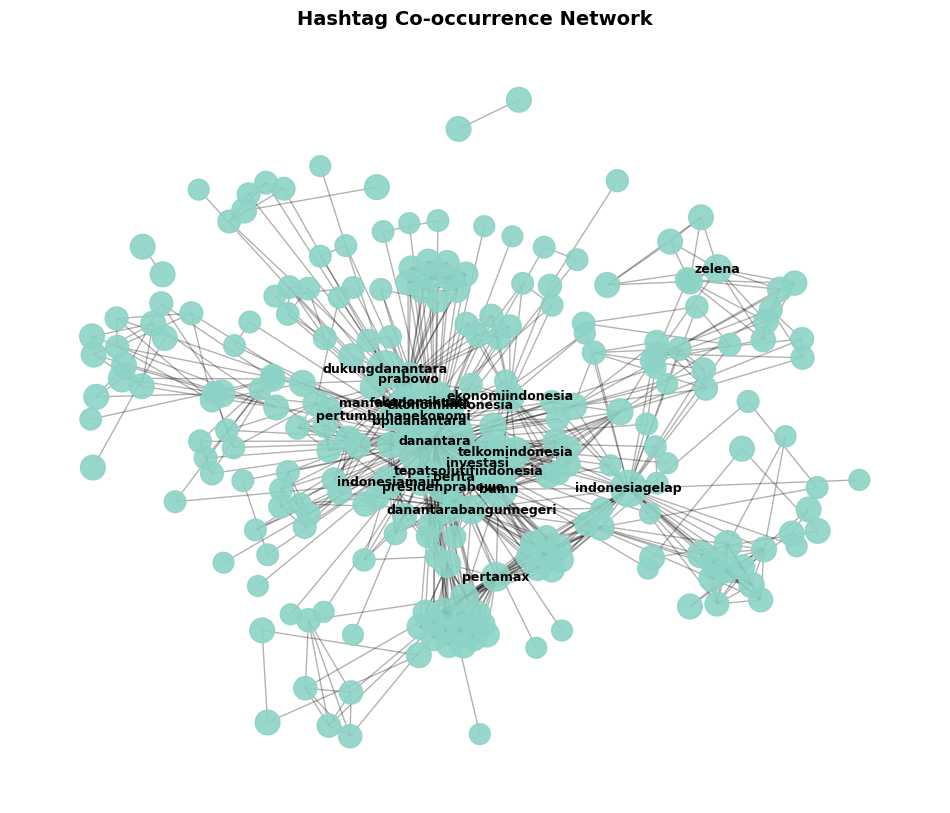

In [55]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

try:
    import community.community_louvain as community_louvain  
    HAS_LOUVAIN = True
except Exception as e:
    print(f"Gagal import python-louvain: {e}")
    HAS_LOUVAIN = False

if HAS_LOUVAIN and G_mention.number_of_nodes() > 0:
    partition = community_louvain.best_partition(G_mention.to_undirected(), random_state=42)
    nx.set_node_attributes(G_mention, partition, "community")
    print("Community detection berhasil — total:", len(set(partition.values())), "komunitas")
else:
    print("Lewati Louvain community detection.")
    partition = {n: 0 for n in G_mention.nodes()}

def visualize_graph(
    G, df_cent, title="Network Visualization",
    topk_label=20, figsize=(12, 10)
):
    if G.number_of_nodes() == 0:
        print("Graph kosong — tidak bisa divisualisasikan.")
        return

    df_cent = df_cent.copy()
    df_cent["pagerank_norm"] = df_cent["pagerank"] / df_cent["pagerank"].max()

    communities = [G.nodes[n].get("community", 0) for n in G.nodes()]
    sizes = [3000 * df_cent.set_index("node").loc[n, "pagerank_norm"] + 200 for n in G.nodes()]

    pos = nx.spring_layout(G, seed=42, k=0.35)

    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(
        G, pos,
        node_color=communities,
        cmap=plt.cm.Set3,
        node_size=sizes,
        alpha=0.9
    )
    nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=False)

    top_nodes = df_cent.head(topk_label)["node"].tolist()
    labels = {n: n for n in top_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight="bold")

    plt.title(title, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()

visualize_graph(G_mention, df_mention_cent, title="Mention Network by Louvain Community & PageRank")
visualize_graph(G_hashtag, df_hashtag_cent, title="Hashtag Co-occurrence Network")
